# overview of the script:
- load the fitted individual-differences model
- load the triplets with their items used in the empirical study by Hebart et al. (2023)
- multiply the object embeddings with the idiosyncratic weightings
- compute the difference between the average model and the id model
- plot delta over number of trials per participant: what would be a good number of trials per participant? -> 440
- plot delta per triplet with number of observations for that triplet on the x axis
- plot triplet delta over triplet agreement: more improvement for less agreed upon triplets
- plot triplet delta over accuracy of the average model: delta as a negatively accelerated function of average model accuracy
- save the triplet deltas

In [1]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2


import plotting as pl
from models import model as md
import utils as ut

In [2]:
import os
import json

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.patches as mpatches

In [3]:
from functools import partial

In [4]:
l_data_subset = ["full_evaluate_actual"]
l_rnd_seed = [1]
l_embed_dim = [25]
modeltype = "free_weights_no_scaling"
modelversion = "embeddings-decision-combined-data"
l_id_weights = ["separate"]
l_lmbda = [1e-07]

l_models, l_results = ut.load_ID_lowdim_id_weights(l_data_subset, l_rnd_seed, l_embed_dim, modelversion, l_lmbda, modeltype, l_id_weights)

In [5]:
triplets_dir = './data/'
device = "cpu"
# load triplets into memory
train_triplets, test_triplets = ut.load_data_ID(
    device=device, triplets_dir=triplets_dir, testcase=False)


...Could not find any .npy files for current modality.
...Now searching for .txt files.



In [6]:
array_weights_items = np.asarray(l_models[0]["item_embeddings"]).T
array_weights_id = l_models[0]["decision_weights"]

In [7]:
anchors = np.array([array_weights_items[i,:] for i in list(test_triplets[:, 0])])
positives = np.array([array_weights_items[i,:] for i in list(test_triplets[:, 1])])
negatives = np.array([array_weights_items[i,:] for i in list(test_triplets[:, 2])])

In [8]:
ids = test_triplets[:, 3].numpy()
ids_unique_sorted = np.sort(np.unique(ids))

anchors_weighted = [a*array_weights_id.numpy()[ids[id], :] for id, a in enumerate(anchors)]
positives_weighted = [a*array_weights_id.numpy()[ids[id], :] for id, a in enumerate(positives)]
negatives_weighted = [a*array_weights_id.numpy()[ids[id], :] for id, a in enumerate(negatives)]

In [9]:
f_partial = partial(ut.delta_avg_id, anchors, positives, negatives, anchors_weighted, positives_weighted, negatives_weighted, ids)

In [10]:
l_deltas = list(map(f_partial, ids_unique_sorted))

In [11]:
deltas_participant = []
for l in l_deltas:
    deltas_participant.append(l[0])

In [12]:
df_ns = pd.DataFrame(ids, columns=['id'])
df_ns = df_ns.groupby("id")["id"].count() * 4
df_ns = df_ns.reset_index(name = "n_train")
df_ns["delta"] = deltas_participant
df_ns["is_improvement"] = (df_ns["delta"] >= 0).astype(int)
prop_triplets_improved = np.round(np.mean(df_ns["is_improvement"], axis=0), 4)
print("prop triplets improved:" + str(prop_triplets_improved))

prop triplets improved:0.8537


C:\Users\MirkoThalmann\AppData\Local\Temp\ipykernel_10264\1482537782.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


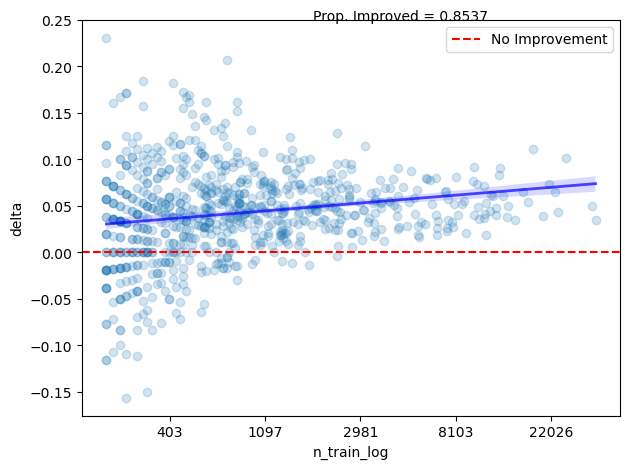

In [13]:
df_ns["n_train_log"] = np.log(df_ns["n_train"])
ax = sns.regplot(
    data=df_ns,
    x="n_train_log",
    y="delta",
    scatter=True,  # Set to False if you only want the smooth line, not the scatter
    line_kws={"color": "blue", "lw": 2, "alpha": .7}, 
    scatter_kws={"alpha": .2}
)

# Customize x-ticks: convert log values back to original
xticks = ax.get_xticks()
xtick_labels = [f"{int(np.round(np.exp(tick)))}" for tick in xticks]
ax.set_xticklabels(xtick_labels)

# Optional extras
ax.axhline(y=0, color="red", linestyle="--", label="No Improvement")
_ = plt.text(x=7.5, y=.25, s=f"Prop. Improved = {prop_triplets_improved}")

plt.legend()
plt.tight_layout()
plt.show()

In [14]:
df_ns["n_train_log_cut"] = pd.cut(df_ns["n_train"], bins=[0, 390, 410, 440, 525, 744, 1265, 2138, 3544, 6114, 10060, 15379, 27061])
df_ns["n_train_cut_nolabel"] = pd.cut(
    df_ns["n_train"], 
    bins=[0, 390, 410, 440, 525, 744, 1265, 2138, 3544, 6114, 10060, 15379, 27061], 
    labels=[390, 410, 440, 525, 744, 1265, 2138, 3544, 6114, 10060, 15379, 27061]
)
df_ns["n_train_cut_nolabel"] = df_ns["n_train_cut_nolabel"].astype("float")

In [15]:
df_ns_agg = df_ns.groupby("n_train_cut_nolabel").agg({"delta": ["count", "mean"]})
# Flatten the MultiIndex columns
df_ns_agg.columns = ['_'.join(col).strip() for col in df_ns_agg.columns.values]
df_ns_agg = df_ns_agg.reset_index()
df_ns_agg["n_train_cut_log"] = np.log(df_ns_agg["n_train_cut_nolabel"])
df_ns_agg.head(10)

,n_train_cut_nolabel,delta_count,delta_mean,n_train_cut_log
0,390.0,243,0.024322,5.966147
1,410.0,15,0.034000,6.016157
2,440.0,21,0.032255,6.086775
3,525.0,54,0.049459,6.263398
4,744.0,111,0.052936,6.612041
5,1265.0,114,0.049643,7.142827
6,2138.0,80,0.050109,7.667626
7,3544.0,56,0.051511,8.173011
8,6114.0,32,0.050955,8.718337
9,10060.0,24,0.048814,9.216322


C:\Users\MirkoThalmann\AppData\Local\Temp\ipykernel_10264\933861096.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


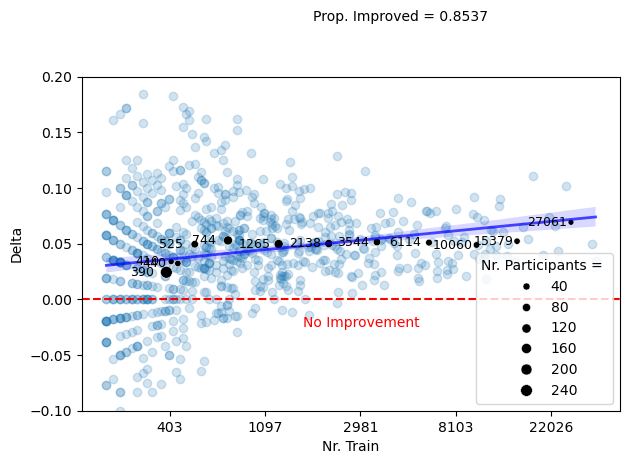

In [16]:
df_ns["n_train_log"] = np.log(df_ns["n_train"])
ax = sns.regplot(
    data=df_ns,
    x="n_train_log",
    y="delta",
    scatter=True,  # Set to False if you only want the smooth line, not the scatter
    line_kws={"color": "blue", "lw": 2, "alpha": .7}, 
    scatter_kws={"alpha": .2}
)

plt.axhline(y=0, color="red", linestyle="--")
plt.text(x=7.4, y=-.025, s="No Improvement", color="red")

# Customize x-ticks: convert log values back to original
xticks = ax.get_xticks()
xtick_labels = [f"{int(np.round(np.exp(tick)))}" for tick in xticks]
ax.set_xticklabels(xtick_labels)
ax.set_ylim((-.1, .2))
ax.set_xlabel("Nr. Train")
ax.set_ylabel("Delta")

# Optional extras
_ = plt.text(x=7.5, y=.25, s=f"Prop. Improved = {prop_triplets_improved}")

scatter = sns.scatterplot(data=df_ns_agg, x="n_train_cut_log", y="delta_mean", size="delta_count", color="black")
# Add text as markers
for _, row in df_ns_agg.iterrows():
    plt.text(
        row["n_train_cut_log"]-.25,
        row["delta_mean"],
        int(row["n_train_cut_nolabel"]),  # replace "label_column" with your text column
        fontsize=9,
        ha='center',
        va='center'
    )
scatter.legend(title="Nr. Participants = ")

plt.tight_layout()
plt.show()

In [17]:
df_diagnostic = pd.read_csv("data/diagnostic-triplets.csv")

In [18]:
df_test_triplets = pd.DataFrame(test_triplets)
df_train_triplets = pd.DataFrame(train_triplets)
df_train_test = pd.concat([df_train_triplets, df_test_triplets], axis=0)

In [19]:
cols = [0, 1, 2]
vals = df_train_test[cols].to_numpy()

# Compute lo, hi, and mid values using vectorized operations
id_lo = np.min(vals, axis=1)
id_hi = np.max(vals, axis=1)

# Calculate id_mid: total - min - max
id_sum = vals.sum(axis=1)
id_mid = id_sum - id_lo - id_hi

# Assign to the DataFrame
df_train_test['id_lo'] = id_lo
df_train_test['id_mid'] = id_mid
df_train_test['id_hi'] = id_hi

df_train_test.rename(columns={3:"id_subject"}, inplace=True)
# filter diagnostic triplets from choices
df_diagnostic_data = pd.merge(df_diagnostic, df_train_test, how="inner", on=["id_lo", "id_mid", "id_hi"])

In [20]:
# Create a string-based triplet_id column from id_lo, id_mid, id_hi
df_diagnostic_data["triplet_id"] = (
    df_diagnostic_data[["id_lo", "id_mid", "id_hi"]]
    .astype(str)
    .agg("".join, axis=1)  # concatenate values without separators
)
df_diagnostic_data["triplet_id"] = pd.Categorical(df_diagnostic_data["triplet_id"])
# Convert to categorical and assign integer labels starting from 1
df_diagnostic_data["triplet_id"] = (
    pd.Categorical(df_diagnostic_data["triplet_id"])
    .rename_categories(lambda x: str(df_diagnostic_data["triplet_id"].cat.categories.get_loc(x) + 1))
)

In [21]:
# note. 0, 1, and 2 in .loc refer to original ordering of the triplets, not 1st, 2nd, and 3rd column of the df
anchors = np.array([array_weights_items[i,:] for i in list(df_diagnostic_data.loc[:, 0])])
positives = np.array([array_weights_items[i,:] for i in list(df_diagnostic_data.loc[:, 1])])
negatives = np.array([array_weights_items[i,:] for i in list(df_diagnostic_data.loc[:, 2])])

In [22]:
# weigh the anchor of every item with the dimension weights for the respective person
anchors_weighted = [a*array_weights_id.numpy()[df_diagnostic_data.loc[id, "id_subject"]] for id, a in enumerate(anchors)]
positives_weighted = [a*array_weights_id.numpy()[df_diagnostic_data.loc[id, "id_subject"]] for id, a in enumerate(positives)]
negatives_weighted = [a*array_weights_id.numpy()[df_diagnostic_data.loc[id, "id_subject"]] for id, a in enumerate(negatives)]

In [23]:
df_items_delta = ut.delta_avg_triplet(
    anchors, positives, negatives, anchors_weighted, positives_weighted, negatives_weighted, 
    array_weights_items, array_weights_id, df_diagnostic_data
)
labels_accuracy_binned = pd.cut(df_items_delta["correct_avg"], 10)

C:\Users\MirkoThalmann\Documents\semantic-representations\utils.py:1973: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_diagnostic_data.groupby("triplet_id")


In [24]:
df_diagnostic_data["n_per_triplet"] = df_diagnostic_data[["n_min", "n_max", "n_med"]].sum(axis=1)

In [25]:
df_items_delta = pd.merge(df_items_delta, df_diagnostic_data[["triplet_id", "id_lo", "id_mid", "id_hi", "prop_max", "n_per_triplet"]].drop_duplicates(), how="left", on="triplet_id")

In [26]:
df_items_delta["is_improvement"] = (df_items_delta["delta"] >= 0).astype(int)
prop_triplets_improved = np.round(np.mean(df_items_delta["is_improvement"], axis=0), 3)
prop_triplets_improved

np.float64(0.867)

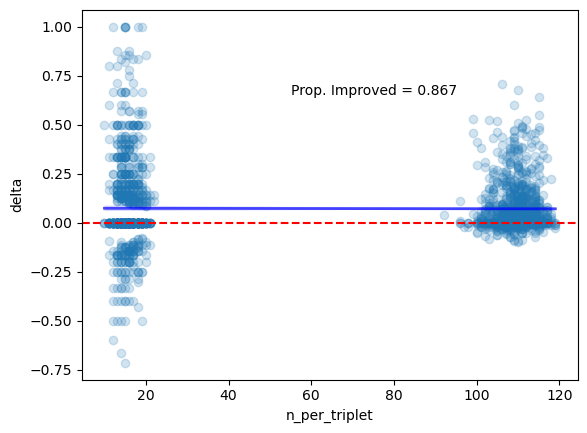

In [27]:
_ = sns.regplot(
    data=df_items_delta,
    x="n_per_triplet",
    y="delta",
    scatter=True,  # Set to False if you only want the smooth line, not the scatter
    line_kws={"color": "blue", "lw": 2, "alpha": .7}, 
    scatter_kws={"alpha": .2}
)
plt.axhline(y=0, color="red", linestyle="--", label="No Improvement")
_ = plt.text(x=55, y=.65, s=f"Prop. Improved = {prop_triplets_improved}")

In [28]:
# Group by 'correct_avg_bin' and compute the weighted average of 'delta'
df_summary = (
    df_items_delta.groupby(["Accuracy Avg. Model"])
    .apply(lambda g: pd.Series({
        "Delta": (g["delta"] * g["n_per_triplet"]).sum() / g["n_per_triplet"].sum(),
        "Total Nr. Responses": g["n_per_triplet"].sum()
    }))
    .reset_index()
)
df_summary["Proportion Responses"] = df_summary["Total Nr. Responses"] / df_summary["Total Nr. Responses"].sum(axis=0)
df_summary["Proportion Delta"] = df_summary["Proportion Responses"] * df_summary["Delta"]

C:\Users\MirkoThalmann\AppData\Local\Temp\ipykernel_10264\3583352406.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


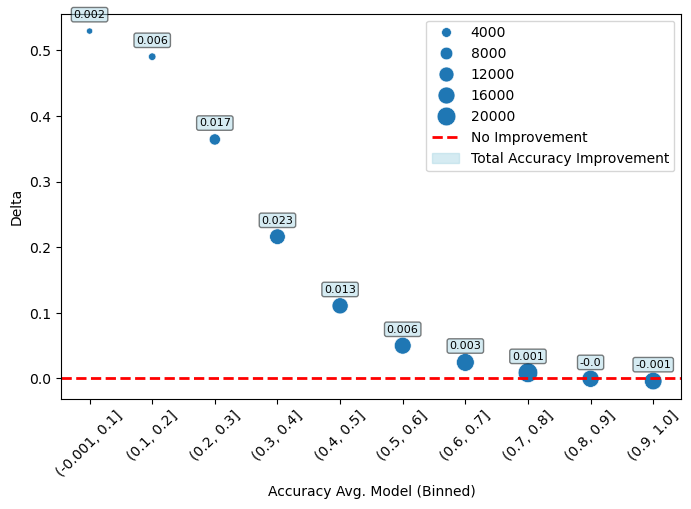

In [29]:
# Step 1: Generate your plot
f, ax = plt.subplots(1, 1, figsize=(8, 5))
scatter = sns.scatterplot(
    data=df_summary,
    x="Accuracy Avg. Model",
    y="Delta",
    size="Total Nr. Responses",
    sizes=(20, 200),
    legend='brief',
    ax=ax, 
)
ax.set_xlabel("Accuracy Avg. Model (Binned)")
# Step 2: Horizontal line with label
ax.axhline(y=0, color="red", linestyle='--', linewidth=2, label='No Improvement')

# Step 3: Add text labels
for i, row in df_summary.iterrows():
    ax.text(
        row["Accuracy Avg. Model"],
        row["Delta"] + 0.025,
        f"{str(np.round(row['Proportion Delta'], 3))}",
        fontsize=8,
        ha='center',
        va='center',
        bbox=dict(boxstyle="round,pad=0.2", fc="lightblue", alpha=0.5)
    )

# Step 4: Create a proxy handle for the ax.text labels
label_proxy = mpatches.Patch(color='lightblue', alpha=0.5, label='Accuracy Improvement')

# Step 5: Combine all handles
handles, labels = ax.get_legend_handles_labels()
handles.append(label_proxy)
labels.append('Total Accuracy Improvement')

# Step 6: Show legend with all entries
ax.legend(handles=handles, labels=labels)

_ = plt.xticks(ticks=range(len(labels_accuracy_binned.cat.categories)),
           labels=labels_accuracy_binned.cat.categories, rotation=45)

In [30]:
# Group by 'correct_avg_bin' and compute the weighted average of 'delta'
df_items_delta["prop_max_rounded"] = np.round(df_items_delta["prop_max"], 1)
df_summary = (
    df_items_delta.groupby(["prop_max_rounded"])
    .apply(lambda g: pd.Series({
        "Delta": (g["delta"] * g["n_per_triplet"]).sum() / g["n_per_triplet"].sum(),
        "Total Nr. Responses": g["n_per_triplet"].sum()
    }))
    .reset_index()
)
df_summary["Proportion Responses"] = df_summary["Total Nr. Responses"] / df_summary["Total Nr. Responses"].sum(axis=0)
df_summary["Proportion Delta"] = df_summary["Proportion Responses"] * df_summary["Delta"]

C:\Users\MirkoThalmann\AppData\Local\Temp\ipykernel_10264\2878315084.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


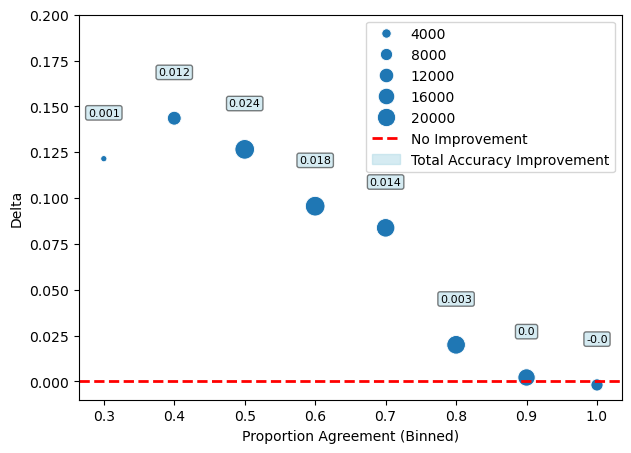

In [31]:
# Step 1: Generate your plot
f, ax = plt.subplots(1, 1, figsize=(7, 5))
scatter = sns.scatterplot(
    data=df_summary,
    x="prop_max_rounded",
    y="Delta",
    size="Total Nr. Responses",
    sizes=(20, 200),
    legend='brief',
    ax=ax, 
)
ax.set_xlabel("Proportion Agreement (Binned)")
# Step 2: Horizontal line with label

# Step 3: Add text labels
for i, row in df_summary.iterrows():
    ax.text(
        row["prop_max_rounded"],
        row["Delta"] + 0.025,
        f"{str(np.round(row['Proportion Delta'], 3))}",
        fontsize=8,
        ha='center',
        va='center',
        bbox=dict(boxstyle="round,pad=0.2", fc="lightblue", alpha=0.5)
    )

# Add horizontal line (don't need to save handle if it gets captured automatically)
ax.axhline(y=0, color="red", linestyle='--', linewidth=2, label='No Improvement')

# Proxy handle for Accuracy Improvement text annotations
label_proxy = mpatches.Patch(color='lightblue', alpha=0.5, label='Accuracy Improvement')

# Collect handles and labels, then deduplicate using a dictionary
handles, labels = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels, handles))  # removes duplicates by label

# Add the custom Accuracy Improvement label, only if it's not already present
legend_dict['Total Accuracy Improvement'] = label_proxy

ax.set_ylim((-0.01, 0.2))

# Draw the final legend
_ = ax.legend(legend_dict.values(), legend_dict.keys())

In [32]:
# save df with information about individual triplets
df_items_delta.to_csv("data/triplets-delta.csv")